# Roads and Libraries

## Problem Statement

Determine the minimum cost to provide library access to all citizens of HackerLand.

There are `n` cities numbered from `1` to `n`.

Currently:
- there are no libraries
- cities are not connected

Bidirectional roads may be built between city pairs listed in `cities`.

A citizen has access to a library if:
1. Their city contains a library
OR
2. They can travel by road to a city containing a library

---

## Goal

Find the minimum total cost required so every city has access to a library.

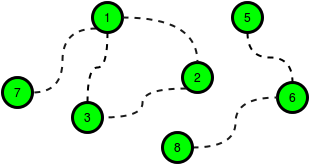

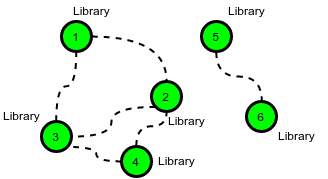

---

# Key Insight

For each connected component:

- Build **1 library**
- Connect remaining cities using roads

Because:
- connecting `k` cities minimally requires:
  
```math
k - 1

Provide library access to every city with minimum total cost.

A city has library access if:
1. It contains a library
OR
2. It can reach a city with a library through roads

Inputs:
- n = number of cities
- c_lib = cost to build a library
- c_road = cost to build a road
- cities = list of bidirectional roads

Key Insight:
- If building a road is more expensive or equal to a library:
    Build a library in every city

- Otherwise:
    For each connected component:
        Build 1 library
        Connect remaining cities with roads

For a connected component of size k:
    cost = c_lib + (k - 1) * c_road

Why?
- To connect k cities with minimum roads:
    need exactly k - 1 roads
- Extra roads create cycles and unnecessary cost


# EDGE CASES

1. c_road >= c_lib
- Build library in every city
- No roads needed

2. Isolated city
- Component size = 1
- Need only 1 library

3. Fully connected graph
- Only 1 library needed
- Remaining cities connected with roads

4. Multiple disconnected components
- Each component needs:
    1 library + roads

5. Cycles in graph
- Ignore unnecessary edges
- DFS/BFS visited prevents double counting

6. No roads
- Every city needs its own library


# PLAN

1. If c_road >= c_lib:
    return n * c_lib

2. Build adjacency list graph

3. Create visited set

4. Iterate through all cities:
    - if city not visited:
        run DFS/BFS
        count component size

5. For each component:
    total_roads = component_size - 1
    total_cost += (
        c_lib +
        total_roadsv * c_road
    )

6. Return total_cost


# COMPLEXITY

Time:
O(V + E)

Space:
O(V + E)

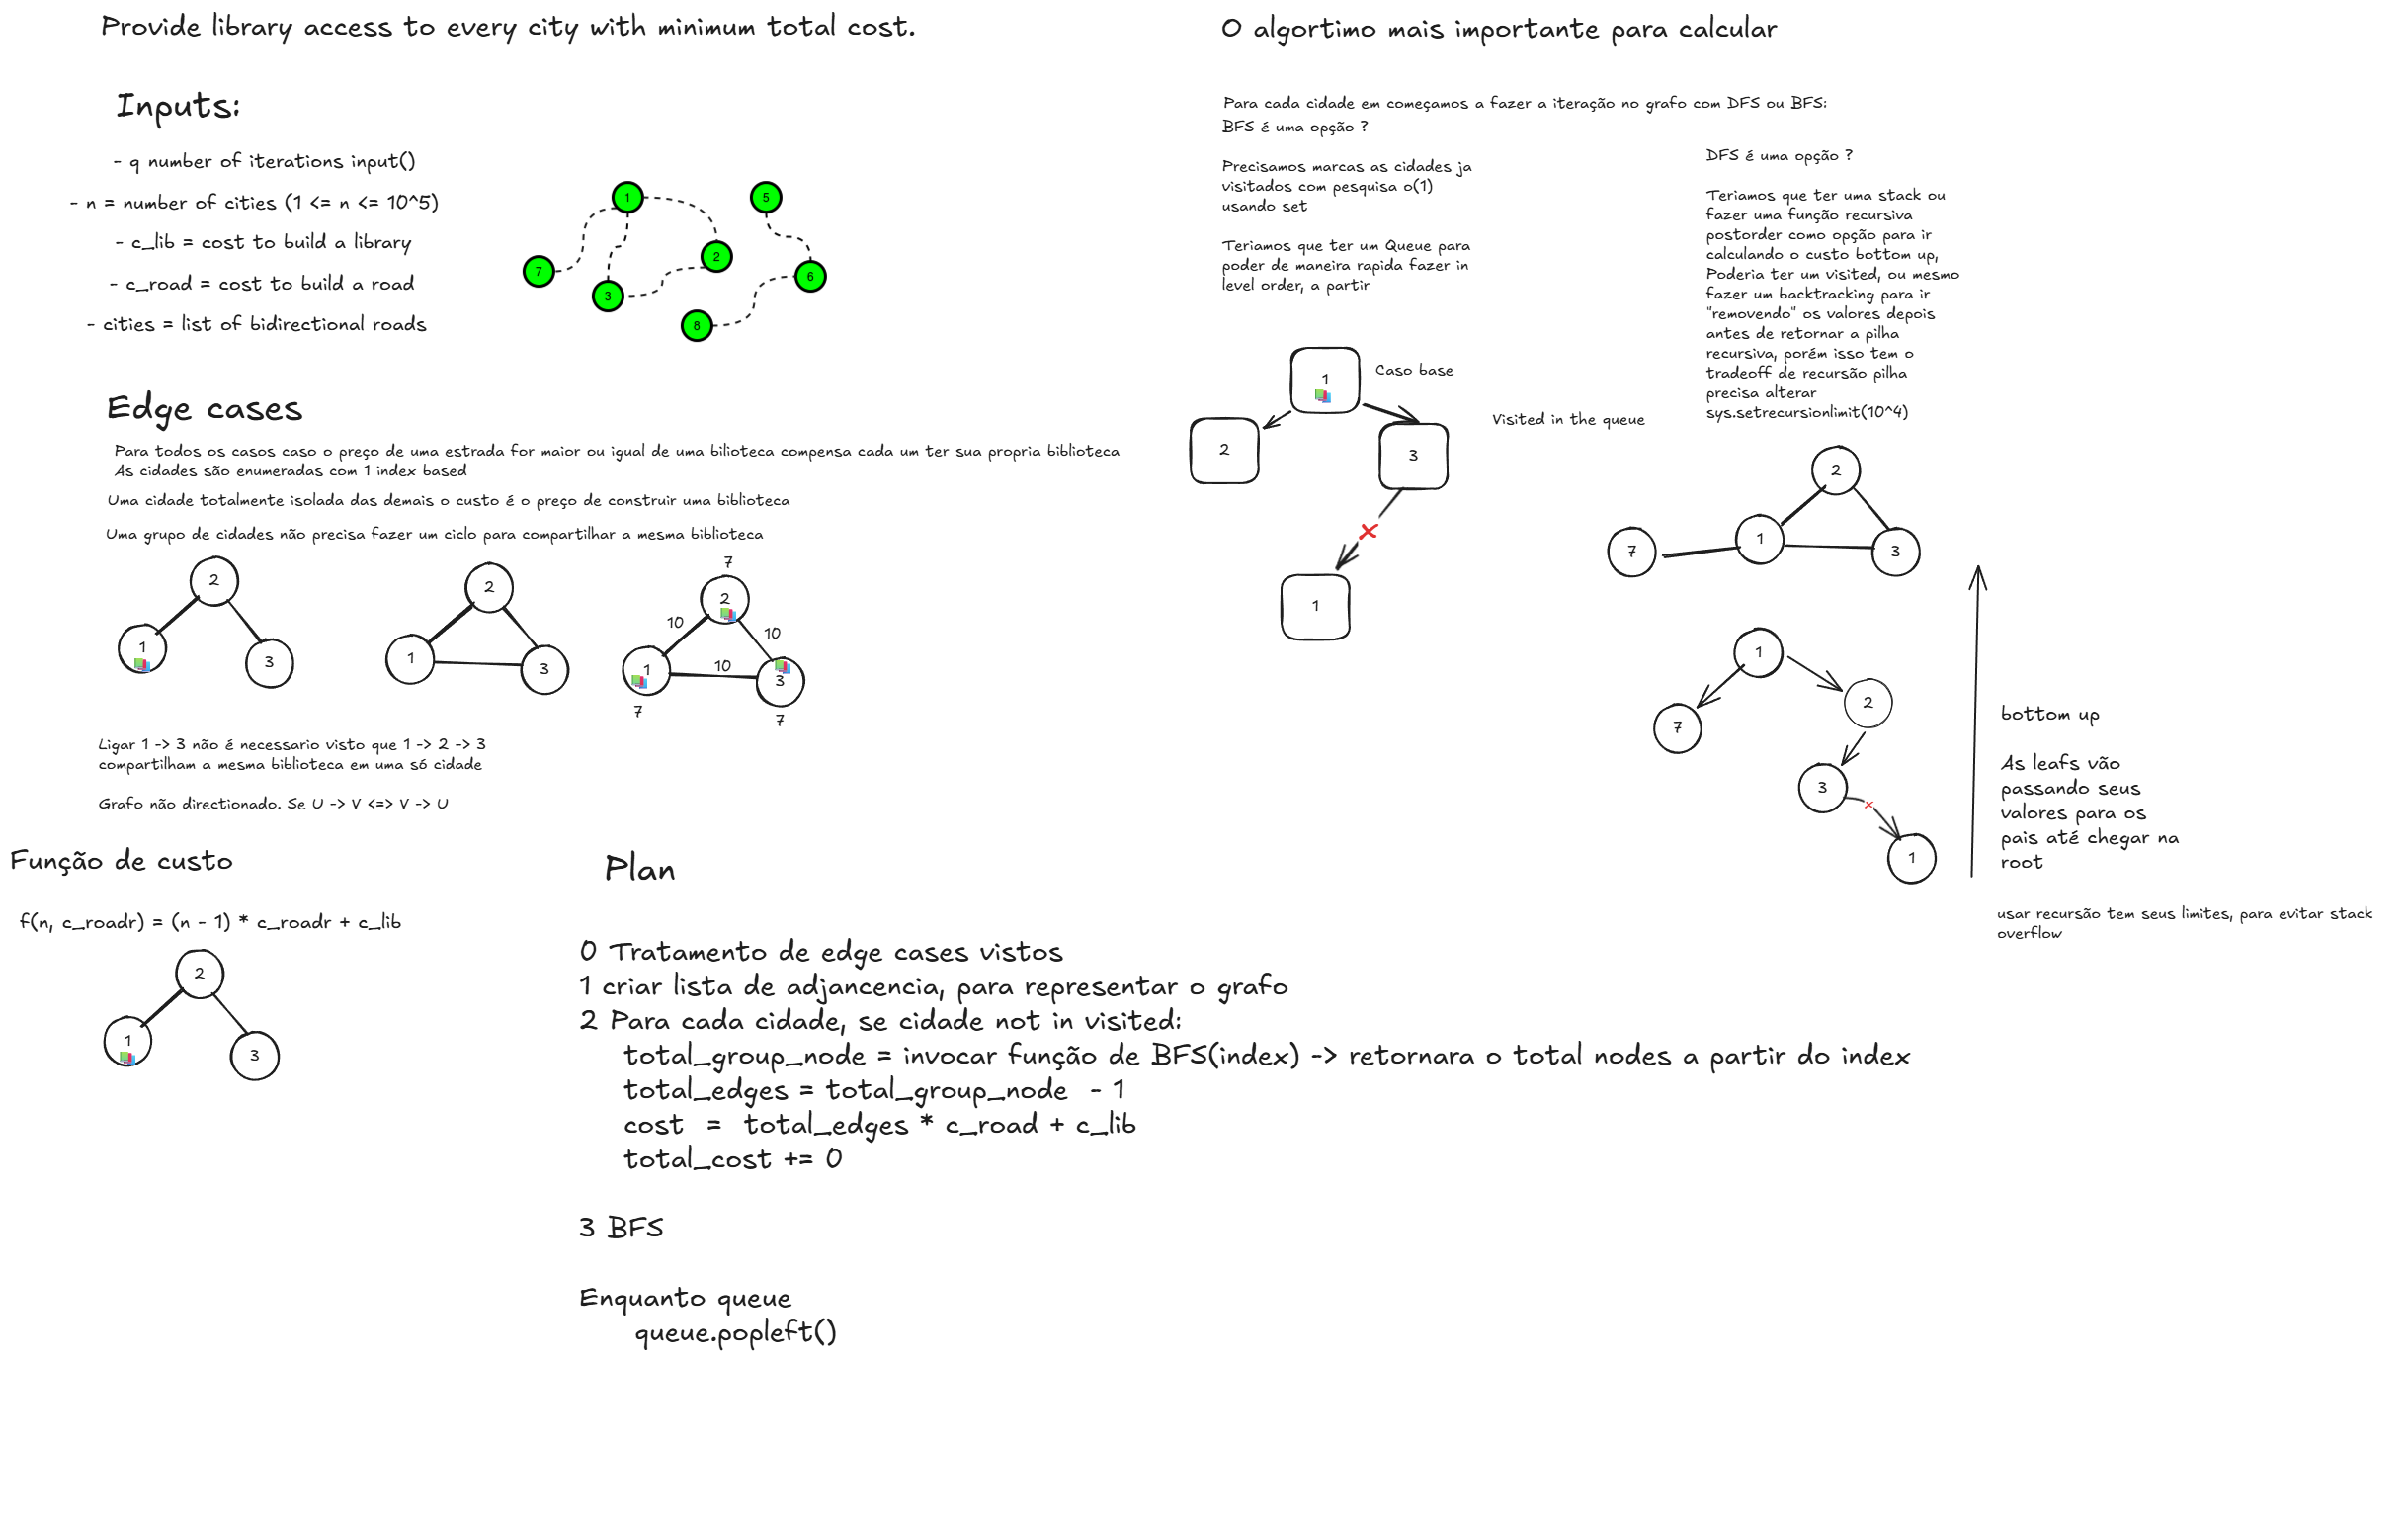

In [ ]:
#!/bin/python3

import os
from collections import defaultdict
from typing import List, Set

# =========================================================
# DFS
# =========================================================

def dfs(
    city: int,
    graph,
    visited: Set[int]
) -> int:

    visited.add(city)

    component_size = 1

    # =====================================================
    # EXPLORE NEIGHBORS
    # =====================================================

    for neighbor in graph[city]:

        if neighbor in visited:
            continue

        component_size += dfs(
            neighbor,
            graph,
            visited
        )

    return component_size


# =========================================================
# MAIN SOLUTION
# =========================================================

def roadsAndLibraries(
    n: int,
    c_lib: int,
    c_road: int,
    cities: List[List[int]]
) -> int:

    # =====================================================
    # IMPORTANT OPTIMIZATION
    # =====================================================

    # roads are useless
    if c_road >= c_lib:

        return n * c_lib

    # =====================================================
    # BUILD GRAPH
    # =====================================================

    graph = defaultdict(list)

    for u, v in cities:

        graph[u].append(v)
        graph[v].append(u)

    # O(E)

    # =====================================================
    # CONNECTED COMPONENTS
    # =====================================================

    visited = set()

    total_cost = 0

    for city in range(1, n + 1):

        if city in visited:
            continue

        # =================================================
        # FIND COMPONENT SIZE
        # =================================================

        component_size = dfs(
            city,
            graph,
            visited
        )
        total_roads = component_size - 1
        # =================================================
        # COST:
        # 1 library
        # remaining roads
        # =================================================

        total_cost += (
            total_roads * c_road + total_roads
        )

    return total_cost


# =========================================================
# DRIVER
# =========================================================

if __name__ == '__main__':

    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    q = int(input().strip())

    for _ in range(q):

        n, m, c_lib, c_road = map(
            int,
            input().rstrip().split()
        )

        cities = []

        for _ in range(m):

            cities.append(
                list(
                    map(
                        int,
                        input().rstrip().split()
                    )
                )
            )

        result = roadsAndLibraries(
            n,
            c_lib,
            c_road,
            cities
        )

        fptr.write(str(result) + '\n')

    fptr.close()
